In [ ]:
# From https://towardsdatascience.com/how-confidence-and-prediction-intervals-work-4592019576d8

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt    
from scipy import stats
import pandas as pd

# pip install uncertainties, if needed
try:
    import uncertainties.unumpy as unp
    import uncertainties as unc
except:
    try:
        from pip import main as pipmain
    except:
        from pip._internal import main as pipmain
    pipmain(['install','uncertainties'])
    import uncertainties.unumpy as unp
    import uncertainties as unc

Optimal Values
a: 0.036141582292222356
b: -0.5735680960487426
R^2: 0.5278048667629538
Uncertainty
a: 0.0361+/-0.0035
b: -0.57+/-0.07


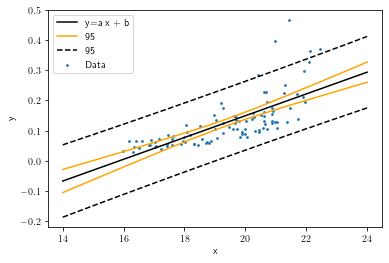

In [7]:
# import data
url = 'https://apmonitor.com/che263/uploads/Main/stats_data.txt'
data = pd.read_csv(url)
x = data['x'].values
y = data['y'].values
n = len(y)

def f(x, a, b):
    return a * x + b

popt, pcov = curve_fit(f, x, y)

# retrieve parameter values
a = popt[0]
b = popt[1]
print('Optimal Values')
print('a: ' + str(a))
print('b: ' + str(b))

# compute r^2
r2 = 1.0-(sum((y-f(x,a,b))**2)/((n-1.0)*np.var(y,ddof=1)))
print('R^2: ' + str(r2))

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)
print('Uncertainty')
print('a: ' + str(a))
print('b: ' + str(b))

# plot data
plt.scatter(x, y, s=3, label='Data')

# calculate regression confidence interval
px = np.linspace(14, 24, 100)
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

def predband(x, xd, yd, p, func, conf=0.95):
    # x = requested points
    # xd = x data
    # yd = y data
    # p = parameters
    # func = function name
    alpha = 1.0 - conf    # significance
    N = xd.size          # data sample size
    var_n = len(p)  # number of parameters
    # Quantile of Student's t distribution for p=(1-alpha/2)
    q = stats.t.ppf(1.0 - alpha / 2.0, N - var_n)
    # Stdev of an individual measurement
    se = np.sqrt(1. / (N - var_n) * \
                 np.sum((yd - func(xd, *p)) ** 2))
    # Auxiliary definitions
    sx = (x - xd.mean()) ** 2
    sxd = np.sum((xd - xd.mean()) ** 2)
    # Predicted values (best-fit model)
    yp = func(x, *p)
    # Prediction band
    dy = q * se * np.sqrt(1.0+ (1.0/N) + (sx/sxd))
    # Upper & lower prediction bands.
    lpb, upb = yp - dy, yp + dy
    return lpb, upb

lpb, upb = predband(px, x, y, popt, f, conf=0.95)

# plot the regression
plt.plot(px, nom, c='black', label='y=a x + b')

# uncertainty lines (95% confidence)
plt.plot(px, nom - 1.96 * std, c='orange',\
         label='95% Confidence Region')
plt.plot(px, nom + 1.96 * std, c='orange')
# prediction band (95% confidence)
plt.plot(px, lpb, 'k--',label='95% Prediction Band')
plt.plot(px, upb, 'k--')
plt.ylabel('y')
plt.xlabel('x')
plt.legend(loc='best')

# save and show figure
# plt.savefig('regression.png')
# plt.show()

# Trying with the advertising data set 

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('text', usetex = True)

In [9]:
# import data

data = pd.read_csv('Advertising.csv',index_col = 0)
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Optimal Values
beta_1: 0.047536640302715386
beta_0: 7.032593578545213
R^2: 0.611875050850071
Uncertainty
a: 0.0475+/-0.0027
b: 7.0+/-0.5


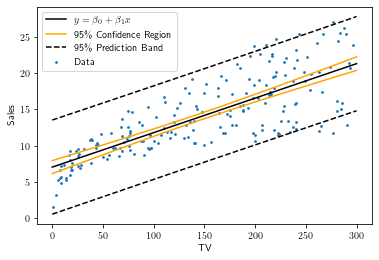

In [10]:

x = data['TV'].values
y = data['Sales'].values
n = len(y)

def f(x, a, b):
    return a * x + b

popt, pcov = curve_fit(f, x, y)

# retrieve parameter values
a = popt[0]
b = popt[1]
print('Optimal Values')
print('beta_1: ' + str(a))
print('beta_0: ' + str(b))

# compute r^2
r2 = 1.0-(sum((y-f(x,a,b))**2)/((n-1.0)*np.var(y,ddof=1)))
print('R^2: ' + str(r2))

# calculate parameter confidence interval
a,b = unc.correlated_values(popt, pcov)
print('Uncertainty')
print('a: ' + str(a))
print('b: ' + str(b))

# plot data
plt.scatter(x, y, s=3, label='Data')

# calculate regression confidence interval
px = np.linspace(0, 300, 100)
py = a*px+b
nom = unp.nominal_values(py)
std = unp.std_devs(py)

def predband(x, xd, yd, p, func, conf=0.95):
    # x = requested points
    # xd = x data
    # yd = y data
    # p = parameters
    # func = function name
    alpha = 1.0 - conf    # significance
    N = xd.size          # data sample size
    var_n = len(p)  # number of parameters
    # Quantile of Student's t distribution for p=(1-alpha/2)
    q = stats.t.ppf(1.0 - alpha / 2.0, N - var_n)
    # Stdev of an individual measurement
    se = np.sqrt(1. / (N - var_n) * \
                 np.sum((yd - func(xd, *p)) ** 2))
    # Auxiliary definitions
    sx = (x - xd.mean()) ** 2
    sxd = np.sum((xd - xd.mean()) ** 2)
    # Predicted values (best-fit model)
    yp = func(x, *p)
    # Prediction band
    dy = q * se * np.sqrt(1.0+ (1.0/N) + (sx/sxd))
    # Upper & lower prediction bands.
    lpb, upb = yp - dy, yp + dy
    return lpb, upb

lpb, upb = predband(px, x, y, popt, f, conf=0.95)

# plot the regression
plt.plot(px, nom, c='black', label=r"$y = \beta_0 + \beta_1 x$")

# uncertainty lines (95% confidence)
plt.plot(px, nom - 1.96 * std, c='orange',\
         label=r'95\% Confidence Region')
plt.plot(px, nom + 1.96 * std, c='orange')
# prediction band (95% confidence)
plt.plot(px, lpb, 'k--',label=r'95\% Prediction Band')
plt.plot(px, upb, 'k--')
plt.ylabel('Sales')
plt.xlabel('TV')
plt.legend(loc='best')

# save and show figure
plt.savefig('Advertising-TV-With-ConfidenceInterval.png', bbox_inches = 'tight')
# plt.show()

In [11]:
?unp.nominal_values

0.0475+/-0.0027


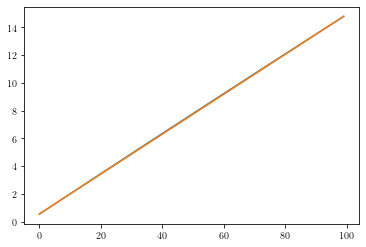

In [41]:
plt.plot(lpb)
# plt.plot(upb)
plt.plot([0,len(lpb)-1],[lpb[0],lpb[-1]])

print(a)

# Version using statsmodel

In [16]:
from statsmodels.stats.outliers_influence import summary_table
import statsmodels.formula.api as smf

In [18]:
# We're going to use the (fake) data set used in the beginning of the book. 
advertising_df = pd.read_csv('Advertising.csv', index_col = 0)
advertising_df

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [72]:
# I need to sort the columns by TV to make plotting work better later 
advertising_df= advertising_df.sort_values(by=['TV'])
advertising_df

,TV,Radio,Newspaper,Sales
131,0.7,39.6,8.7,1.6
156,4.1,11.6,5.7,3.2
79,5.4,29.9,9.4,5.3
57,7.3,28.1,41.4,5.5
127,7.8,38.9,50.6,6.6
...,...,...,...,...
99,289.7,42.3,51.2,25.4
36,290.7,4.1,8.5,12.8
31,292.9,28.3,43.2,21.4
43,293.6,27.7,1.8,20.7


In [73]:
x = advertising_df['TV'].values
y = advertising_df['Sales'].values

In [74]:
##ANSWER##
est = smf.ols('Sales ~ TV', advertising_df).fit()
est.params

Intercept    7.032594
TV           0.047537
dtype: float64

In [98]:
# st, data, ss2 = summary_table(est, alpha=0.01)

# fittedvalues = data[:, 2]
# predict_mean_se  = data[:, 3]
# predict_mean_ci_low, predict_mean_ci_upp = data[:, 4:6].T
# predict_ci_low, predict_ci_upp = data[:, 6:8].T

In [101]:
advert_summary = est.get_prediction(advertising_df).summary_frame(alpha=0.001)
advert_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,7.065869,0.456216,5.541951,8.589787,-3.925310,18.057048
1,7.227494,0.448345,5.729870,8.725118,-3.760070,18.215058
2,7.289291,0.445348,5.801678,8.776905,-3.696913,18.275495
3,7.379611,0.440981,5.906584,8.852638,-3.604627,18.363849
4,7.403379,0.439835,5.934182,8.872577,-3.580346,18.387105
...,...,...,...,...,...,...
195,20.803958,0.447687,19.308531,22.299386,9.816693,31.791223
196,20.851495,0.449996,19.348355,22.354635,9.863178,31.839812
197,20.956076,0.455091,19.435918,22.476233,9.965418,31.946734
198,20.989351,0.456716,19.463765,22.514937,9.997941,31.980761


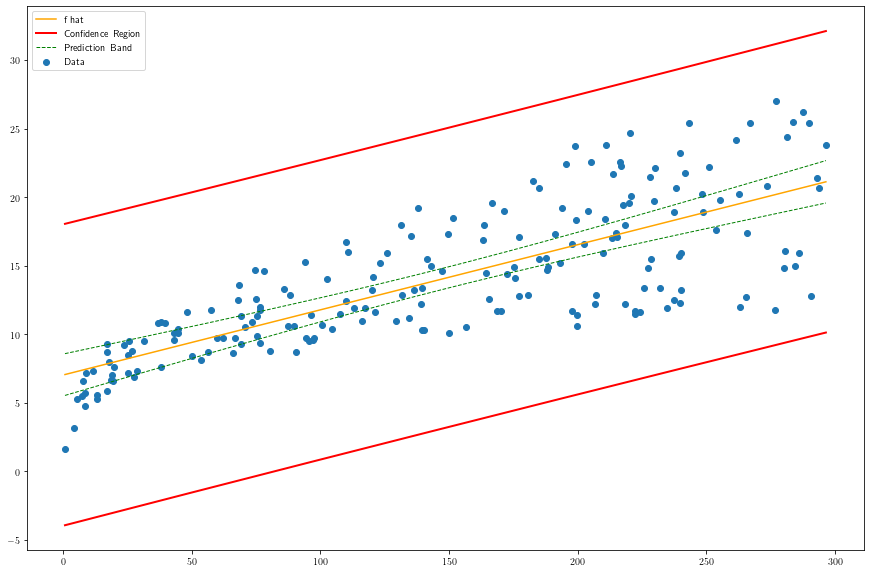

In [102]:
plt.rcParams['figure.figsize'] = [15, 10]

# Plot the original data 
plt.scatter(x,y, label = 'Data')

# Plot the fitted values, AKA f_hat
plt.plot(x,est.fittedvalues, color = 'orange', label = 'f hat')



plt.plot(x,advert_summary['obs_ci_lower'], 'r', lw=2, 
         label = r'Confidence Region')
plt.plot(x,advert_summary['obs_ci_upper'], 'r', lw=2)

plt.plot(x, advert_summary['mean_ci_lower'],'g--', lw=1, 
         label = r'Prediction Band')
plt.plot(x, advert_summary['mean_ci_upper'], 'g--', lw=1)


# From the other code......
# # uncertainty lines (95% confidence)
# plt.plot(px, nom - 1.96 * std, c='orange',\
#          label=r'95\% Confidence Region')
# plt.plot(px, nom + 1.96 * std, c='orange')
# # prediction band (95% confidence)
# plt.plot(px, lpb, 'k--',label=r'95\% Prediction Band')
# plt.plot(px, upb, 'k--')

plt.legend()

In [105]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Wed, 14 Sep 2022   Prob (F-statistic):           1.47e-42
Time:                        10:37:45   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

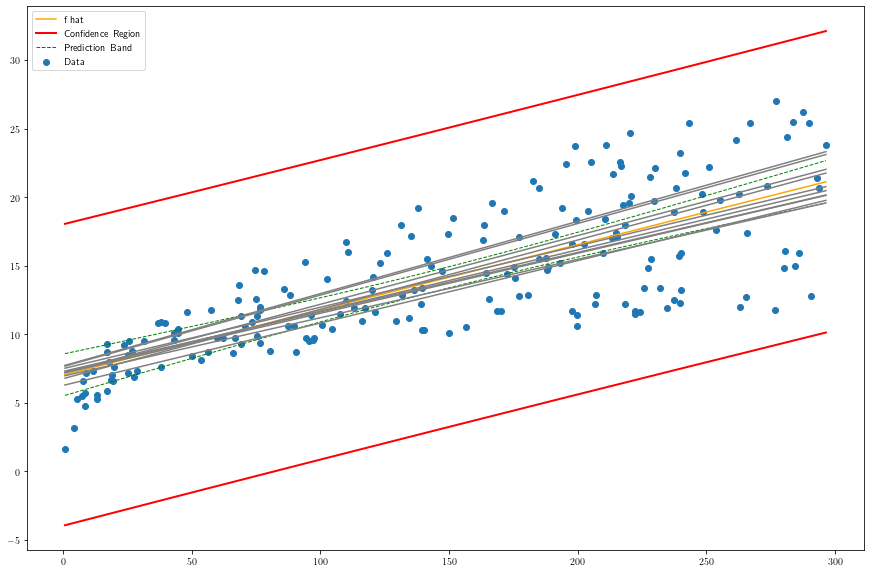

In [115]:
plt.rcParams['figure.figsize'] = [15, 10]

# Plot the original data 
plt.scatter(x,y, label = 'Data')

# Plot the fitted values, AKA f_hat
plt.plot(x,est.fittedvalues, color = 'orange', label = 'f hat')



plt.plot(x,advert_summary['obs_ci_lower'], 'r', lw=2, 
         label = r'Confidence Region')
plt.plot(x,advert_summary['obs_ci_upper'], 'r', lw=2)

plt.plot(x, advert_summary['mean_ci_lower'],'g--', lw=1, 
         label = r'Prediction Band')
plt.plot(x, advert_summary['mean_ci_upper'], 'g--', lw=1)


# From the other code......
# # uncertainty lines (95% confidence)
# plt.plot(px, nom - 1.96 * std, c='orange',\
#          label=r'95\% Confidence Region')
# plt.plot(px, nom + 1.96 * std, c='orange')
# # prediction band (95% confidence)
# plt.plot(px, lpb, 'k--',label=r'95\% Prediction Band')
# plt.plot(px, upb, 'k--')

plt.legend()



ci_intercept = [6.130, 7.935]
ci_TV = [0.042, 0.053]


for i in range(10):
    random_intercept = np.random.uniform(ci_intercept[0], ci_intercept[1])
#     print(random_intercept)

    random_TV = np.random.uniform(ci_TV[0], ci_TV[1])
#     print(random_TV)
    plt.plot(x, random_TV*x + random_intercept, color = 'grey')

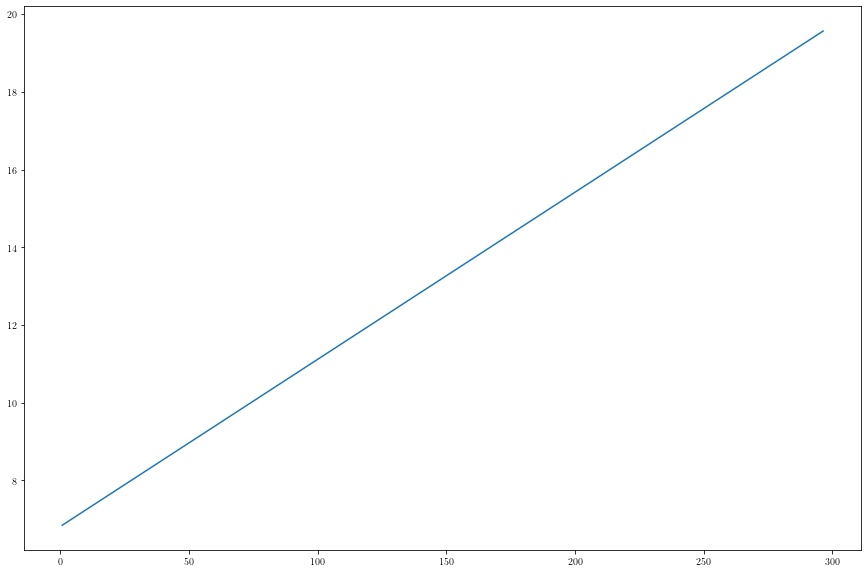